# Titanic — Exploratory Data Analysis

## 1. Load & Initial Inspection

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

# Load dataset
df = sns.load_dataset("titanic")

# Initial inspection
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())
print(df.head())

(891, 15)
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min   

## 2. Data Cleaning

In [43]:
# Fill nulls
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Drop columns with too many nulls or irrelevant for analysis
df = df.drop(columns=["deck", "embark_town", "alive", "who", "adult_male"])
print(df.isnull().sum())
print(df.shape)

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
class       0
alone       0
dtype: int64
(891, 10)


## 3. Feature Engineering

In [44]:
# Family size: passenger + siblings/spouses + parents/children
df["family_size"] = df["sibsp"] + df["parch"] + 1

# Age group
conditions = [df["age"] < 18, df["age"] <= 60]
choices    = ["child", "adult"]
df["age_group"] = np.select(conditions, choices, default="senior")
print(df[["age", "family_size", "age_group"]].head(10))

    age  family_size age_group
0  22.0            2     adult
1  38.0            2     adult
2  26.0            1     adult
3  35.0            2     adult
4  35.0            1     adult
5  28.0            1     adult
6  54.0            1     adult
7   2.0            5     child
8  27.0            3     adult
9  14.0            2     child


## 4. NumPy Analysis

In [45]:
# --- 4.1 Survival rate by passenger class ---

# pclass has values 1, 2, 3
# For each class: extract the "survived" column as a numpy array
# and calculate the mean (mean of 0s and 1s = proportion)
for pclass in sorted(df["pclass"].unique()):
    # Extract survived values for this class as numpy array
    survived_arr = df[df["pclass"] == pclass]["survived"].to_numpy()
    # np.mean of binary array = survival rate
    rate = np.mean(survived_arr)
    count = len(survived_arr)
    print(f"Class {pclass}: {count} passengers, survival rate = {rate:.2%}")

# --- 4.2 Manual descriptive statistics on "age" ---

age_arr = df["age"].to_numpy()   # extract as numpy array
print(f"\nAge statistics:")
print(f"  mean:   {np.mean(age_arr):.2f}")
print(f"  median: {np.median(age_arr):.2f}")
print(f"  std:    {np.std(age_arr):.2f}")
print(f"  min:    {np.min(age_arr):.2f}")
print(f"  max:    {np.max(age_arr):.2f}")
print(f"  q25:    {np.percentile(age_arr, 25):.2f}")
print(f"  q75:    {np.percentile(age_arr, 75):.2f}")

# --- 4.3 Manual descriptive statistics on "fare" ---

fare_arr = df["fare"].to_numpy()
print(f"\nFare statistics:")
print(f"  mean:   {np.mean(fare_arr):.2f}")
print(f"  median: {np.median(fare_arr):.2f}")
print(f"  std:    {np.std(fare_arr):.2f}")
print(f"  max:    {np.max(fare_arr):.2f}")

# Note: mean >> median on fare → strong right skew (a few very expensive tickets)
# This is something you'll confirm visually in section 5

Class 1: 216 passengers, survival rate = 62.96%
Class 2: 184 passengers, survival rate = 47.28%
Class 3: 491 passengers, survival rate = 24.24%

Age statistics:
  mean:   29.36
  median: 28.00
  std:    13.01
  min:    0.42
  max:    80.00
  q25:    22.00
  q75:    35.00

Fare statistics:
  mean:   32.20
  median: 14.45
  std:    49.67
  max:    512.33


## 5. Visualizations

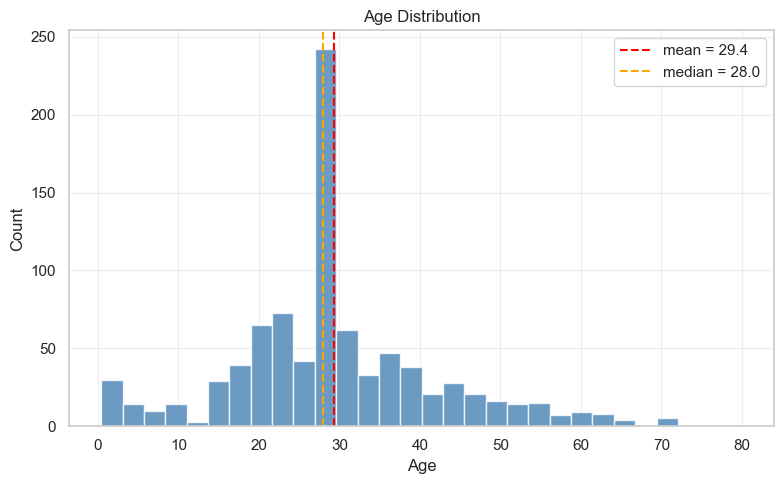

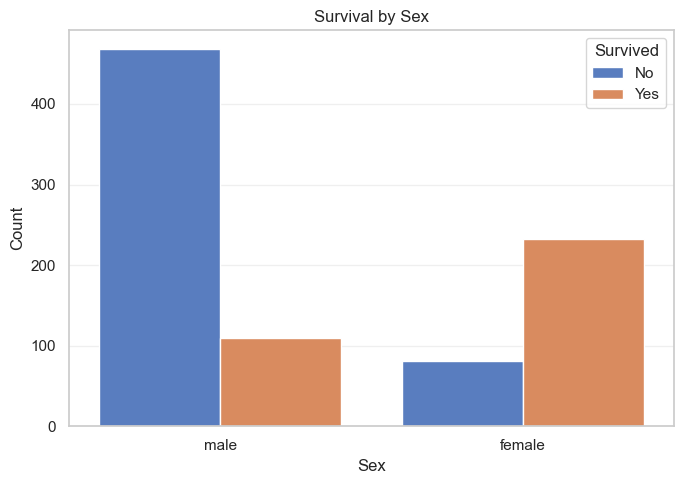

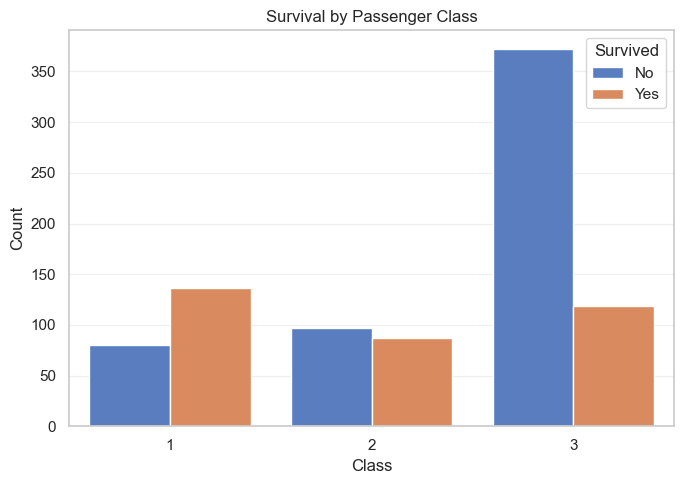

/var/folders/3g/7rw_kkw10dv75zzhl1907ltw0000gn/T/ipykernel_66163/2569776139.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(fare_by_class, labels=[f"Class {p}" for p in pclasses], patch_artist=True)


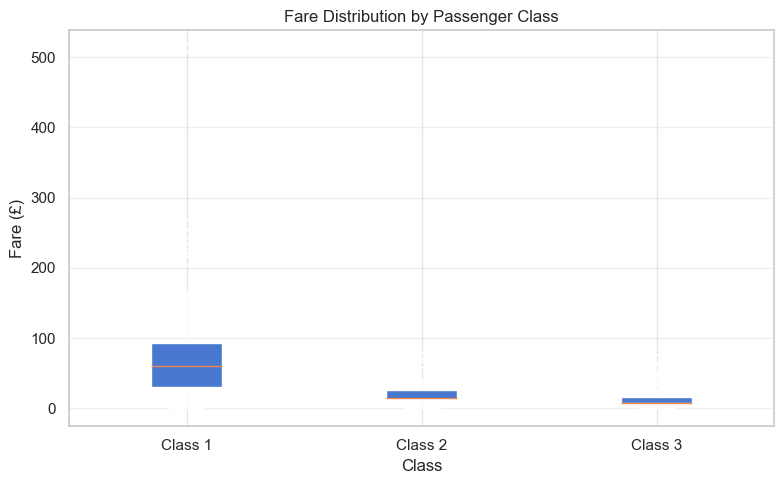

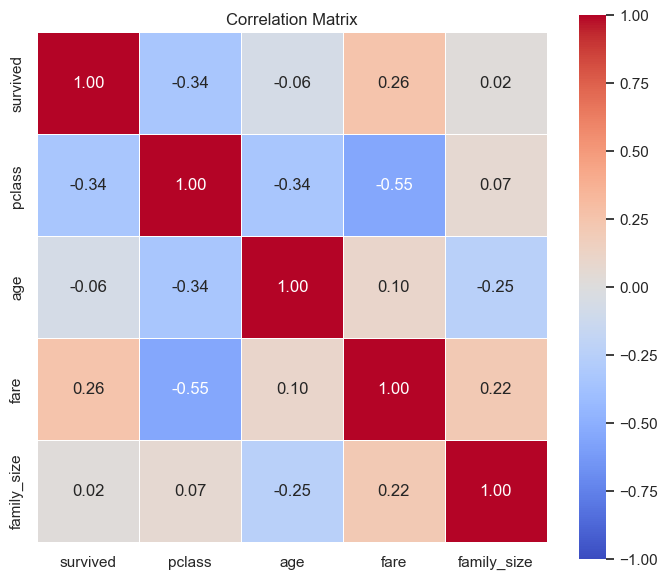

In [46]:
# --- 5.1 Age distribution ---

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["age"], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(np.mean(df["age"].to_numpy()), color="red",
           linestyle="--", label=f"mean = {df['age'].mean():.1f}")
ax.axvline(np.median(df["age"].to_numpy()), color="orange",
           linestyle="--", label=f"median = {df['age'].median():.1f}")
ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot_1_age_distribution.png", dpi=150)
plt.show()

# --- 5.2 Survival by sex ---

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x="sex", hue="survived", palette="muted", ax=ax)
ax.set_title("Survival by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Count")
ax.legend(title="Survived", labels=["No", "Yes"])
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot_2_survival_by_sex.png", dpi=150)
plt.show()

# --- 5.3 Survival by passenger class ---

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x="pclass", hue="survived", palette="muted", ax=ax)
ax.set_title("Survival by Passenger Class")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.legend(title="Survived", labels=["No", "Yes"])
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot_3_survival_by_class.png", dpi=150)
plt.show()

# --- 5.4 Fare distribution by class (boxplot) ---

# Same pattern as Bloque 4 exercise 2:
# 1. get unique groups sorted
# 2. extract arrays per group
# 3. pass list to boxplot()
pclasses = sorted(df["pclass"].unique())
fare_by_class = [df[df["pclass"] == p]["fare"].values for p in pclasses]
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(fare_by_class, labels=[f"Class {p}" for p in pclasses], patch_artist=True)
ax.set_title("Fare Distribution by Passenger Class")
ax.set_xlabel("Class")
ax.set_ylabel("Fare (£)")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot_4_fare_by_class.png", dpi=150)
plt.show()

# --- 5.5 Correlation heatmap ---

# Only numeric columns relevant for analysis
numeric_cols = ["survived", "pclass", "age", "fare", "family_size"]
corr_matrix  = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.savefig("plot_5_correlation.png", dpi=150)
plt.show()

## 6. Conclusions

1. Sex is the strongest survival predictor: ~74% of women survived vs ~19% of men.
2. Passenger class correlates negatively with survival: 1st class ~63%, 3rd class ~24%.
3. Age distribution is right-skewed — mean (29.7) > median (28.0).
4. Fare distribution is heavily right-skewed with significant outliers in 1st class.
5. Family size shows weak positive correlation with survival.